# 📊 Análise Exploratória dos Dados

## 📁 Contexto

Este projeto visa a construção de um modelo de chatbot baseado em técnicas tradicionais de Machine Learning. Os dados utilizados foram gerados sinteticamente e simulam interações de perguntas e respostas categorizadas por temas específicos.

O conjunto de dados contém as colunas:

- `pergunta`: a pergunta feita pelo usuário.
- `categoria`: o tema ao qual a pergunta pertence.
- `resposta`: a resposta correspondente à pergunta.

---

## 📐 Dimensão do Conjunto de Dados

- Total de observações: **10.000**
- Total de colunas: **3**
  - `pergunta`
  - `categoria`
  - `resposta`

---

## 🔍 Verificação de Nulos

- Não foram encontrados valores nulos em nenhuma das colunas.

---

## 📊 Distribuição das Categorias

Foi analisada a quantidade de perguntas por categoria para entender o balanceamento entre as classes.

*Inserir gráfico aqui (ex: barras com matplotlib/seaborn)*

- Quantidade total de categorias: **9**
- As categorias estão **relativamente balanceadas**, com pequenas variações entre elas.

---

## 🧮 Estatísticas Descritivas

### Média de caracteres por coluna:

- `pergunta`: aproximadamente **35 a 50** caracteres por linha.
- `resposta`: média um pouco maior que a da pergunta, cerca de **60 a 80** caracteres.
- `categoria`: como esperado, os nomes são curtos (~10 caracteres).

---

## ✅ Conclusões da Análise

- Os dados estão **completos** (sem valores ausentes).
- Há uma **boa variedade de categorias**, simulando um FAQ realista.
- As classes estão **bem representadas** e não exigem técnicas de balanceamento.
- O tamanho médio dos textos permite um pré-processamento simples de NLP.
- O dataset é adequado para **treinamento e avaliação de modelos supervisionados**.

---

## 📌 Próximos Passos

- Pré-processamento dos dados (`TF-IDF`, limpeza de texto, etc.).
- Treinamento e avaliação de modelos de classificação.
- Salvamento do modelo e construção da API do chatbot.



# Todo processo realizado abaixo

## Imports

In [19]:
import pandas as pd
import random
import matplotlib.pyplot as plt

## Criando dados sintéticos

In [2]:
# Categorias e respostas genéricas
categorias_respostas = {
    "cardiologia": "Você pode agendar uma consulta com um cardiologista pelo nosso site ou aplicativo.",
    "consultas": "Para marcar consultas, acesse nosso portal ou entre em contato pelo telefone.",
    "convenios": "Trabalhamos com diversos convênios. Consulte a lista completa em nosso site.",
    "dermatologia": "Dermatologistas atendem de segunda a sexta, das 9h às 17h.",
    "gripe": "Se estiver com sintomas de gripe, procure um clínico geral.",
    "neurologia": "Temos especialistas em neurologia disponíveis para agendamento.",
    "nutricao": "Nossa equipe de nutrição oferece atendimento personalizado.",
    "ortopedia": "A ortopedia atende casos de fraturas, dores musculares e articulares.",
    "saude_mental": "Nosso time de saúde mental está disponível para apoiar você com psicólogos e psiquiatras."
}

# Variações e ruídos nas perguntas por categoria
perguntas_exemplos = {
    "cardiologia": [
        "Preciso de um cardio", "Consulta com cardiologista", "quero marcar com especialista do coração",
        "dor no peito, o q fazer?", "tem cardiologistas aí?", "qual o valor da cardiologia?"
    ],
    "consultas": [
        "quero agendar uma consulta", "como marcar consulta?", "tem como marcar?", "consulta", 
        "agendamento de médico", "preciso consultar um médico urgente"
    ],
    "convenios": [
        "quais convênios aceitam?", "aceita plano de saúde?", "trabalham com a unimed?", "convenios",
        "meu convênio cobre?", "planos de saúde disponíveis?"
    ],
    "dermatologia": [
        "to com alergia na pele", "tem dermato aí?", "consulta dermatologista", "coceira no corpo",
        "manchas estranhas", "preciso de um dermatologista urgente"
    ],
    "gripe": [
        "to gripado", "tosse e febre", "gripe forte", "remédio pra gripe", "o que fazer com sintomas gripais?", 
        "estou com dor no corpo e garganta"
    ],
    "neurologia": [
        "dores de cabeça constantes", "problemas neurológicos", "tem neuro?", "crises epilépticas",
        "especialista em cérebro", "preciso de neurologista"
    ],
    "nutricao": [
        "quero uma dieta", "nutricionista", "emagrecer com ajuda médica", "dieta personalizada",
        "consultar com nutri", "quero mudar minha alimentação"
    ],
    "ortopedia": [
        "machuquei o joelho", "tem ortopedista?", "dor no osso", "consulta ortopedia",
        "problema de coluna", "preciso de exame ortopédico"
    ],
    "saude_mental": [
        "estou ansioso", "preciso de psicólogo", "sintomas de depressão", "tristeza constante", 
        "ajuda emocional", "problemas de saúde mental"
    ]
}

# Função para gerar o dataset
def gerar_dataset_faq(n=10000):
    dados = []
    for _ in range(n):
        categoria = random.choice(list(categorias_respostas.keys()))
        pergunta = random.choice(perguntas_exemplos[categoria])
        resposta = categorias_respostas[categoria]
        dados.append({"pergunta": pergunta, "categoria": categoria, "resposta": resposta})
    return pd.DataFrame(dados)

# Gerar dataset
df_faq = gerar_dataset_faq(10000)
df_faq.to_csv('../data/processed/nlp_chatbot_dataset.csv')

## Visualizando as primeiras linhas do conjunto de dados

In [3]:
df_faq.head(10)

,pergunta,categoria,resposta
0,como marcar consulta?,consultas,"Para marcar consultas, acesse nosso portal ou ..."
1,preciso de um dermatologista urgente,dermatologia,"Dermatologistas atendem de segunda a sexta, da..."
2,dieta personalizada,nutricao,Nossa equipe de nutrição oferece atendimento p...
3,quero marcar com especialista do coração,cardiologia,Você pode agendar uma consulta com um cardiolo...
4,emagrecer com ajuda médica,nutricao,Nossa equipe de nutrição oferece atendimento p...
5,gripe forte,gripe,"Se estiver com sintomas de gripe, procure um c..."
6,quais convênios aceitam?,convenios,Trabalhamos com diversos convênios. Consulte a...
7,quero marcar com especialista do coração,cardiologia,Você pode agendar uma consulta com um cardiolo...
8,dor no osso,ortopedia,"A ortopedia atende casos de fraturas, dores mu..."
9,aceita plano de saúde?,convenios,Trabalhamos com diversos convênios. Consulte a...


## Salvando dados no diretório data/raw

In [4]:
df_faq.to_csv('../data/raw/chatbot_medical_data.csv')

## Lendo arquivo salvo

In [5]:
df = pd.read_csv('../data/raw/chatbot_medical_data.csv').drop('Unnamed: 0', axis=1)
df.head(10)

,pergunta,categoria,resposta
0,como marcar consulta?,consultas,"Para marcar consultas, acesse nosso portal ou ..."
1,preciso de um dermatologista urgente,dermatologia,"Dermatologistas atendem de segunda a sexta, da..."
2,dieta personalizada,nutricao,Nossa equipe de nutrição oferece atendimento p...
3,quero marcar com especialista do coração,cardiologia,Você pode agendar uma consulta com um cardiolo...
4,emagrecer com ajuda médica,nutricao,Nossa equipe de nutrição oferece atendimento p...
5,gripe forte,gripe,"Se estiver com sintomas de gripe, procure um c..."
6,quais convênios aceitam?,convenios,Trabalhamos com diversos convênios. Consulte a...
7,quero marcar com especialista do coração,cardiologia,Você pode agendar uma consulta com um cardiolo...
8,dor no osso,ortopedia,"A ortopedia atende casos de fraturas, dores mu..."
9,aceita plano de saúde?,convenios,Trabalhamos com diversos convênios. Consulte a...


## Explorando dataset

### Verificando colunas

In [6]:
df.columns

Index(['pergunta', 'categoria', 'resposta'], dtype='object')

### Verificando dimensões do dataset

In [7]:
df.shape

(10000, 3)

### Verificando a existência de valores nulos

In [8]:
df.isna().sum()

pergunta     0
categoria    0
resposta     0
dtype: int64

### Verificando a média da quantidade de carcteres de cada coluna

In [14]:
df['qtde_caracteres_pergunta'] = df.pergunta.apply(lambda x: len(x))
df['qtde_caracteres_categoria'] = df.categoria.apply(lambda x: len(x))
df['qtde_caracteres_resposta'] = df.resposta.apply(lambda x: len(x))

print('Média de qtde de caracteres da coluna [pergunta]:', df.qtde_caracteres_pergunta.mean())
print('Média de qtde de caracteres da coluna [categoria]:', df.qtde_caracteres_categoria.mean())
print('Média de qtde de caracteres da coluna [resposta]:', df.qtde_caracteres_resposta.mean())

Média de qtde de caracteres da coluna [pergunta]: 20.7433
Média de qtde de caracteres da coluna [categoria]: 9.4736
Média de qtde de caracteres da coluna [resposta]: 70.3584


### Verificando os tipos de categorias

In [16]:
df.categoria.unique()

array(['consultas', 'dermatologia', 'nutricao', 'cardiologia', 'gripe',
       'convenios', 'ortopedia', 'neurologia', 'saude_mental'],
      dtype=object)

### Verificando o balanceamento da coluna categoria

In [20]:
categorias = df.categoria.value_counts()
categorias

categoria
cardiologia     1146
saude_mental    1134
convenios       1124
dermatologia    1124
consultas       1104
ortopedia       1097
neurologia      1095
nutricao        1093
gripe           1083
Name: count, dtype: int64

### Verificando tipo de dado das colunas

In [28]:
df.dtypes

pergunta                     object
categoria                    object
resposta                     object
qtde_caracteres_pergunta      int64
qtde_caracteres_categoria     int64
qtde_caracteres_resposta      int64
dtype: object

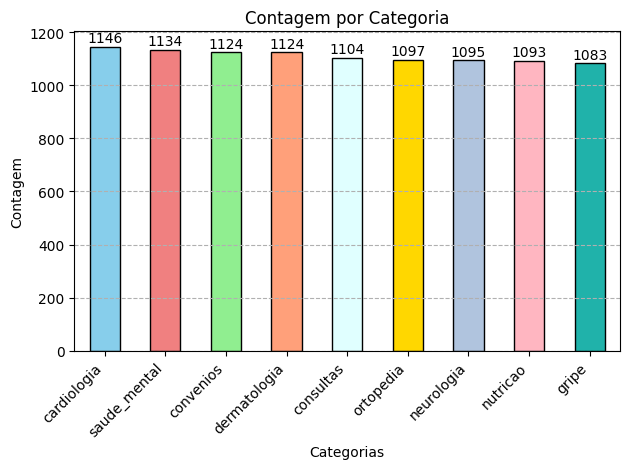

In [27]:
# Lista de cores personalizadas
cores_personalizadas = ['skyblue', 'lightcoral', 'lightgreen', 'lightsalmon', 'lightcyan',
                        'gold', 'lightsteelblue', 'lightpink', 'lightseagreen']

# Plotando gráfico de barras
categorias.plot(kind='bar', color=cores_personalizadas, edgecolor='black')

# Adicionando rótulos e título
plt.xlabel('Categorias')
plt.ylabel('Contagem')
plt.title('Contagem por Categoria')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Adicionando os valores acima das barras
for i, v in enumerate(categorias):
    plt.text(i, v + 5, str(v), ha='center', va='bottom')

# Exibindo o gráfico
plt.grid(axis='y', linestyle='--')
plt.show()